In [23]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path(r".")  # you are inside interim_data

FILES = [
    "Battery.csv",
    "EffusionCell.csv",
    "HeaterBank.csv",
    "Orbit.csv",
    "PowerBus.csv",
    "SimulationEngine.csv",
    "SolarArray.csv",
    "wake_4probes.csv",
]

WAKE_COLS = [
    "tick",
    "phys_time_s",
    "P_FRONT_Torr",
    "P_WAKE_Torr",
    "P_FREE_Torr",
    "P_GAP_Torr",
    "cup_scale",
    "CUP_EMIT_real_per_s",
    "Fwafer_log_cm2s",
    "mbe_active",
]


In [24]:
def read_generic_table(path: Path) -> pd.DataFrame | None:
    """
    Reads a subsystem log that might be comma-separated OR whitespace-separated.
    """
    if not path.exists():
        return None

    # try CSV first
    try:
        df = pd.read_csv(path)
        if len(df) == 0:
            return None
        return df
    except Exception:
        pass

    # fallback: whitespace-separated
    try:
        df = pd.read_csv(path, delim_whitespace=True, engine="python")
        if len(df) == 0:
            return None
        return df
    except Exception:
        return None

def read_wake_csv(path: Path) -> pd.DataFrame | None:
    """
    wake_4probes.csv:
    - contains random '# comment' lines throughout the file
    - data lines are comma-separated and have 10 fields
    """
    if not path.exists():
        return None

    df = pd.read_csv(
        path,
        header=None,
        names=WAKE_COLS,
        comment="#",          # <-- ignores comment lines anywhere
        engine="python"       # more tolerant of weird formatting
    )

    df = df.dropna(how="all")
    return df if len(df) else None

def detect_tick_col(df: pd.DataFrame):
    for c in ["tick", "Tick", "TICK", "step", "Step", "time", "Time", "t"]:
        if c in df.columns:
            return c
    for c in df.columns:
        if c.lower().endswith("tick"):
            return c
    return None


In [25]:
def align_wake_to_simengine(wake: pd.DataFrame, sim: pd.DataFrame, sim_tick_col: str):
    """
    Spec:
    - wake row 1 aligns with sim row 2
    - drop sim tick 1 (sim row 1)
    - wake ticks are NOT trusted
    """
    sim_sorted = sim.sort_values(sim_tick_col).reset_index(drop=True)

    # sim row 2..end ticks (index 1..)
    target_ticks = sim_sorted.loc[1:, sim_tick_col].to_numpy()

    # wake is one less row; guard anyway
    n = min(len(wake), len(target_ticks))
    wake_aligned = wake.iloc[:n].copy()

    # overwrite wake tick with corresponding sim tick
    wake_aligned[sim_tick_col] = target_ticks[:n]

    # drop sim tick 1
    sim_dropped = sim_sorted.loc[1:].copy()

    return wake_aligned, sim_dropped


In [26]:
def aggregate_one_job(job_dir: Path, verbose: bool = False) -> pd.DataFrame:
    job_name = job_dir.name

    sim_path = job_dir / "SimulationEngine.csv"
    sim = read_generic_table(sim_path)
    if sim is None:
        if verbose:
            print(f"[skip] {job_name}: missing/unreadable SimulationEngine.csv")
        return pd.DataFrame()

    sim_tick = detect_tick_col(sim)
    if sim_tick is None:
        raise ValueError(f"{job_name}: Could not detect tick column in SimulationEngine.csv")

    sim = sim.copy()
    sim["job_name"] = job_name

    # wake special case
    wake_path = job_dir / "wake_4probes.csv"
    wake = read_wake_csv(wake_path)
    if wake is not None:
        wake_aligned, sim = align_wake_to_simengine(wake, sim, sim_tick)
        wake_aligned = wake_aligned.rename(columns={c: f"wake.{c}" for c in wake_aligned.columns if c != sim_tick})
        sim = sim.merge(wake_aligned, on=sim_tick, how="left")

    # merge remaining subsystem files
    for fname in FILES:
        if fname in ["SimulationEngine.csv", "wake_4probes.csv"]:
            continue

        part = read_generic_table(job_dir / fname)
        if part is None:
            continue

        part_tick = detect_tick_col(part)
        if part_tick is None:
            if verbose:
                print(f"[warn] {job_name}: {fname} has no tick column; skipping")
            continue

        part = part.copy()
        if part_tick != sim_tick:
            part = part.rename(columns={part_tick: sim_tick})

        prefix = fname.replace(".csv", "")
        part = part.rename(columns={c: f"{prefix}.{c}" for c in part.columns if c != sim_tick})

        sim = sim.merge(part, on=sim_tick, how="left")

    sim = sim.sort_values([sim_tick]).reset_index(drop=True)
    sim["row_in_job"] = np.arange(len(sim), dtype=int)
    sim["sim_tick_col"] = sim_tick
    return sim


In [27]:
subdirs = sorted([p for p in ROOT.iterdir() if p.is_dir()])
print("Subdirs under interim_data:", [d.name for d in subdirs])

dfs = []
for d in subdirs:
    try:
        df_job = aggregate_one_job(d, verbose=True)
        if len(df_job) == 0:
            continue
        dfs.append(df_job)
        print(f"[ok] {d.name}: {df_job.shape}")
    except Exception as e:
        print(f"[fail] {d.name}: {e}")

df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
print("FINAL df shape:", df.shape)
df.head()


Subdirs under interim_data: ['jobs2', 'jobs4', 'jobs5', 'jobs6', 'jobs7', 'orbit1', 'orbit2']
[ok] jobs2: (692, 52)
[ok] jobs4: (589, 52)
[ok] jobs5: (1000, 52)
[ok] jobs6: (582, 52)
[ok] jobs7: (468, 52)
[ok] orbit1: (678, 52)
[ok] orbit2: (723, 52)
FINAL df shape: (4732, 52)


,tick,time_s,status,bus,battery,solar,job_failed,job_name,wake.phys_time_s,wake.P_FRONT_Torr,...,PowerBus.granted,PowerBus.remaining,SolarArray.time_s,SolarArray.status,SolarArray.solar_scale,SolarArray.solar_input,SolarArray.output,SolarArray.efficiency,row_in_job,sim_tick_col
0,1,60,1,0,503.333,1698.20,0,jobs2,60.0,1.874929e-08,...,0.0,1698.20,60,1,0.998883,5660.67,1698.20,0.3,0,tick
1,2,120,1,0,506.667,1692.52,0,jobs2,120.0,3.614022e-08,...,0.0,1692.52,120,1,0.995539,5641.72,1692.52,0.3,1,tick
2,3,180,1,0,510.000,1683.07,0,jobs2,180.0,3.722670e-08,...,0.0,1683.07,180,1,0.989981,5610.22,1683.07,0.3,2,tick
3,4,240,1,0,513.333,1669.90,0,jobs2,240.0,3.734387e-08,...,0.0,1669.90,240,1,0.982235,5566.32,1669.90,0.3,3,tick
4,5,300,1,0,516.667,1653.07,0,jobs2,300.0,3.676593e-08,...,0.0,1653.07,300,1,0.972335,5510.22,1653.07,0.3,4,tick


In [28]:
if df.empty:
    raise RuntimeError("Aggregated df is empty. Check your folder paths and file names.")

sim_tick_col = df["sim_tick_col"].mode().iloc[0]
job0 = df["job_name"].value_counts().index[0]
d0 = df[df["job_name"] == job0].sort_values(sim_tick_col).reset_index(drop=True)

print("Example job:", job0)
print("First 5 sim ticks:", d0[sim_tick_col].head(5).tolist())

wake_cols = [c for c in d0.columns if c.startswith("wake.")]
print("Wake cols:", len(wake_cols))

if wake_cols:
    display(d0[[sim_tick_col] + wake_cols[:6]].head(8))
else:
    print("No wake columns merged (wake file missing or unreadable for this job).")


Example job: jobs5
First 5 sim ticks: [1, 2, 3, 4, 5]
Wake cols: 9


,tick,wake.phys_time_s,wake.P_FRONT_Torr,wake.P_WAKE_Torr,wake.P_FREE_Torr,wake.P_GAP_Torr,wake.cup_scale
0,1,60.0,1.874929e-08,6.932325e-11,4.851700e-11,1.139653e-09,0.533396
1,2,120.0,3.614022e-08,1.222819e-10,7.967855e-11,1.381385e-09,0.566643
2,3,180.0,3.722670e-08,1.348138e-10,8.846850e-11,1.391222e-09,0.599593
3,4,240.0,3.734387e-08,1.237308e-10,8.717552e-11,1.390117e-09,0.632098
4,5,60.0,1.874448e-08,1.466867e-10,8.778464e-11,2.545741e-09,0.533396
5,6,120.0,3.623545e-08,2.423169e-10,1.477507e-10,2.942176e-09,0.566643
6,7,180.0,3.676995e-08,2.606492e-10,1.566784e-10,2.936696e-09,0.599593
7,8,240.0,3.746667e-08,2.389253e-10,1.555238e-10,2.918856e-09,0.632098


In [29]:
import numpy as np
import matplotlib.pyplot as plt

sim_tick_col = df["sim_tick_col"].mode().iloc[0] if "sim_tick_col" in df.columns else "tick"
print("Using tick col:", sim_tick_col)

def pick_cols(substrs, max_k=6):
    cols = []
    for s in substrs:
        cols += [c for c in df.columns if s.lower() in c.lower()]
    # unique preserve order
    seen = set()
    out = []
    for c in cols:
        if c not in seen and c != sim_tick_col:
            seen.add(c)
            out.append(c)
    return out[:max_k]


Using tick col: tick


fail_col: job_failed


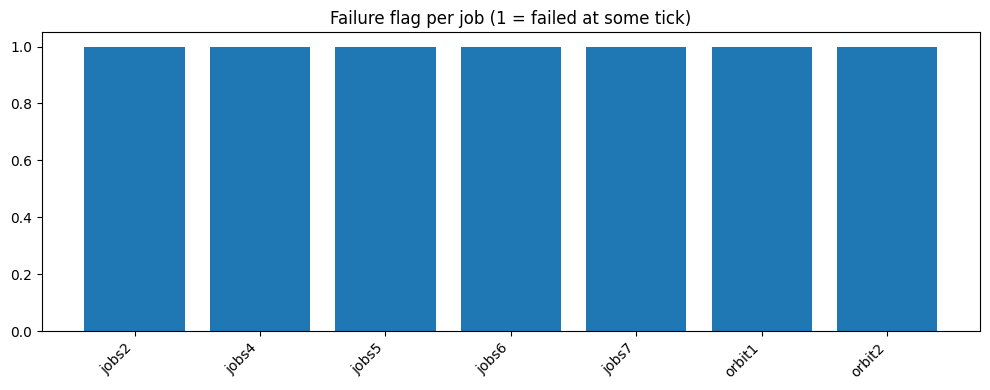

Failure rate: 1.0 ( 7 failed of 7 )


In [30]:
fail_col = None
for c in df.columns:
    if c.lower().endswith("job_failed") or c.lower().endswith(".job_failed"):
        fail_col = c
        break

print("fail_col:", fail_col)

if fail_col:
    job_fail = df.groupby("job_name")[fail_col].max().sort_values(ascending=False)
    plt.figure(figsize=(10, 4))
    plt.bar(job_fail.index.astype(str), job_fail.values)
    plt.xticks(rotation=45, ha="right")
    plt.title("Failure flag per job (1 = failed at some tick)")
    plt.tight_layout()
    plt.show()

    fail_rate = job_fail.mean()
    print("Failure rate:", float(fail_rate), "(", int(job_fail.sum()), "failed of", len(job_fail), ")")
else:
    print("No fail column found.")


Job: jobs5
Plot cols: ['battery', 'Battery.time_s', 'solar', 'Orbit.solar_scale', 'PowerBus.granted', 'PowerBus.remaining', 'PowerBus.requested']


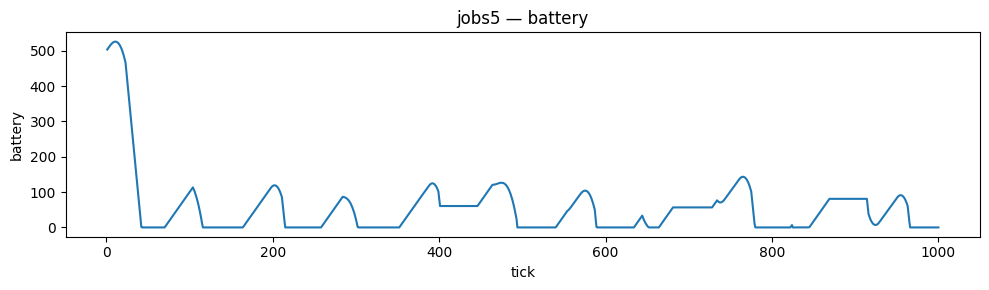

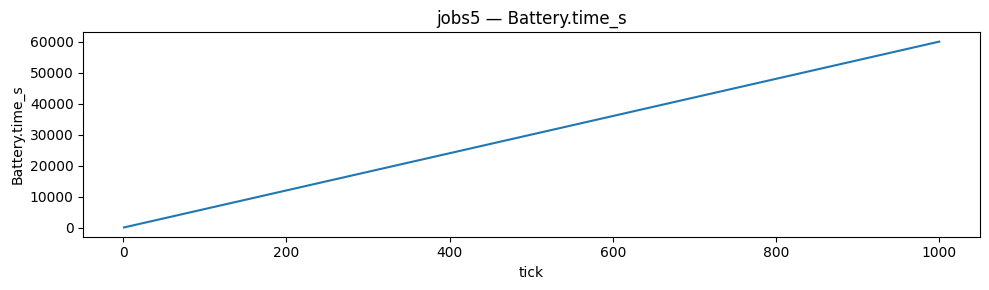

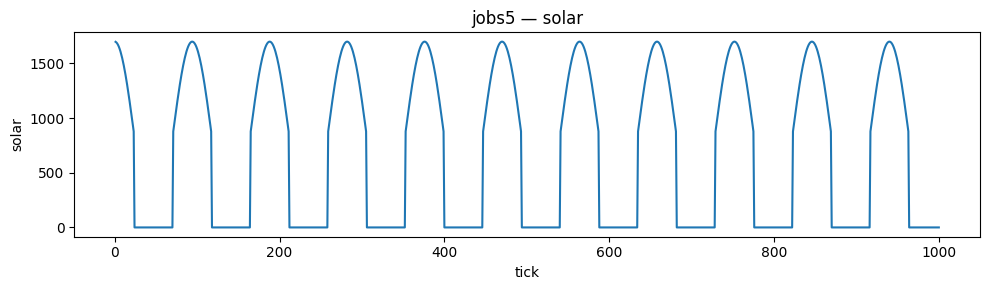

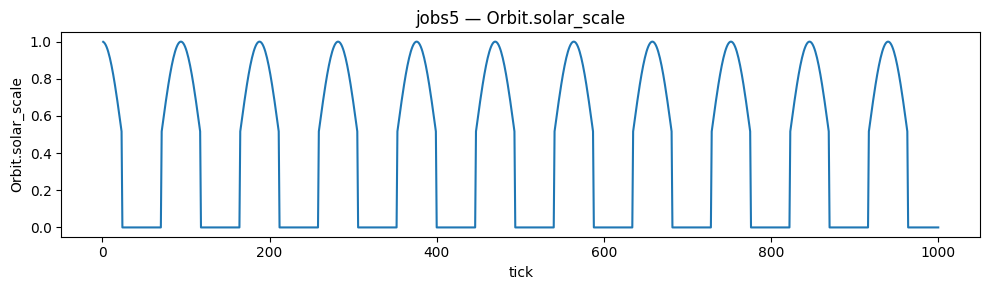

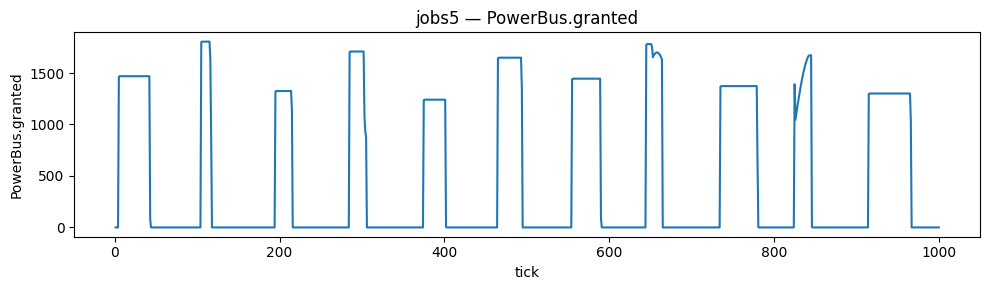

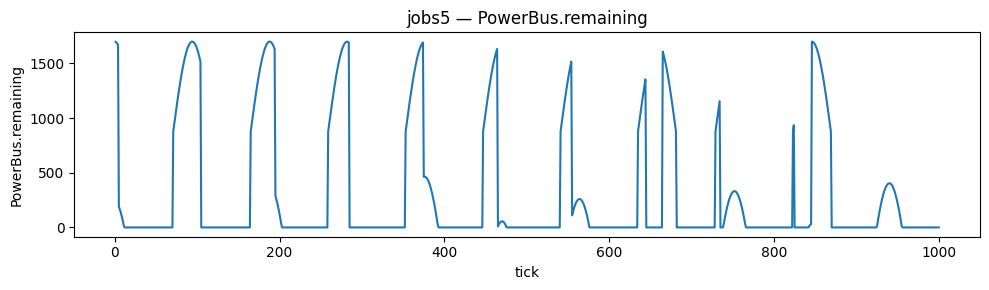

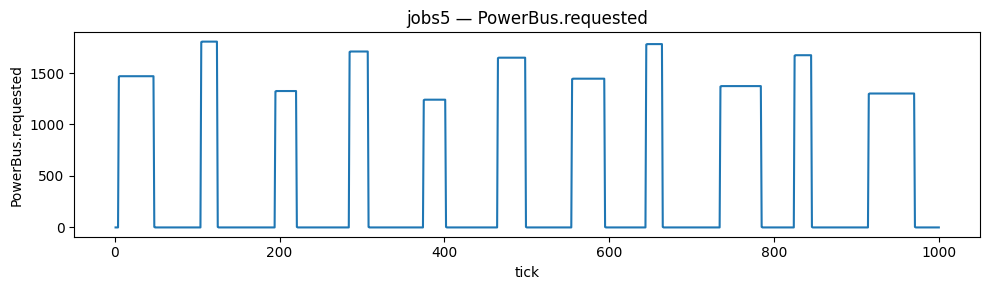

In [31]:
job_to_plot = df["job_name"].value_counts().index[0]
d = df[df["job_name"] == job_to_plot].sort_values(sim_tick_col).reset_index(drop=True)

cols = []
cols += pick_cols(["battery", "soc"], max_k=2)
cols += pick_cols(["solar"], max_k=2)
cols += pick_cols(["PowerBus.granted", "PowerBus.remaining", "PowerBus.requested"], max_k=3)

# fallback: anything with power-ish name
if not cols:
    cols = pick_cols(["power", "watt", "bus"], max_k=6)

print("Job:", job_to_plot)
print("Plot cols:", cols)

for c in cols:
    if c not in d.columns:
        continue
    plt.figure(figsize=(10, 3))
    plt.plot(d[sim_tick_col], d[c])
    plt.title(f"{job_to_plot} — {c}")
    plt.xlabel(sim_tick_col)
    plt.ylabel(c)
    plt.tight_layout()
    plt.show()


Job: jobs5
Wake pressure cols: ['wake.P_FRONT_Torr', 'wake.P_WAKE_Torr', 'wake.P_FREE_Torr', 'wake.P_GAP_Torr']


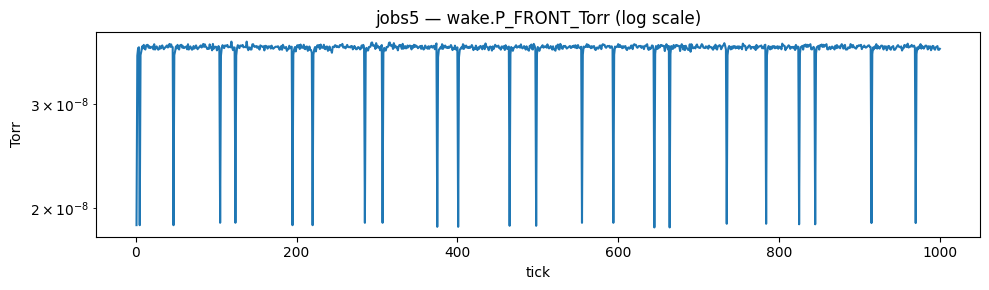

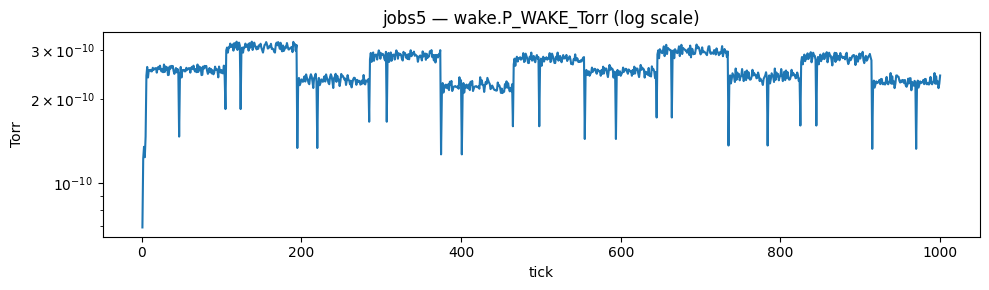

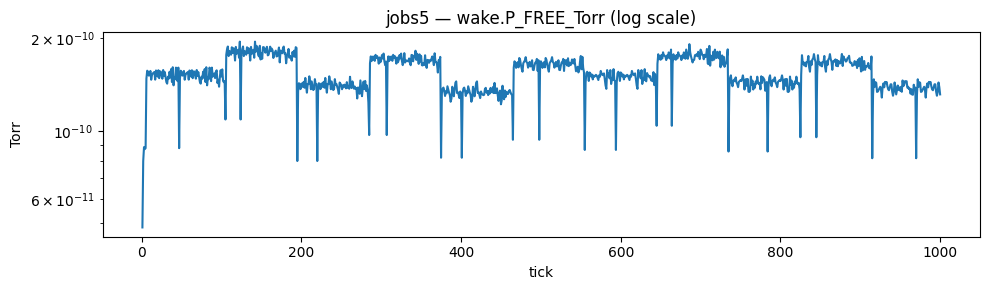

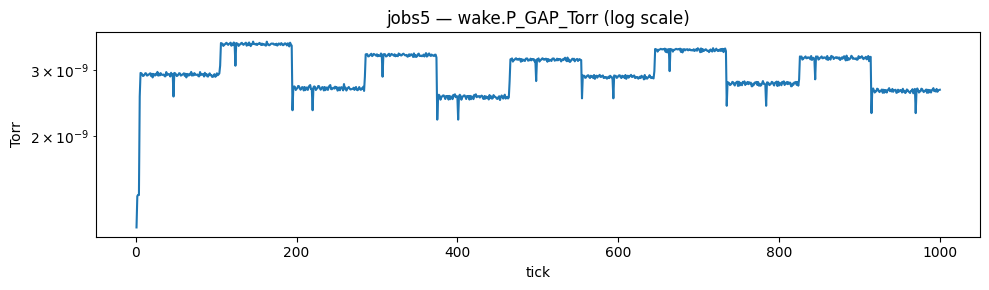

Comparing column: wake.P_WAKE_Torr


C:\Users\Risha\AppData\Local\Temp\ipykernel_22416\3646980374.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=jobs, showfliers=False)


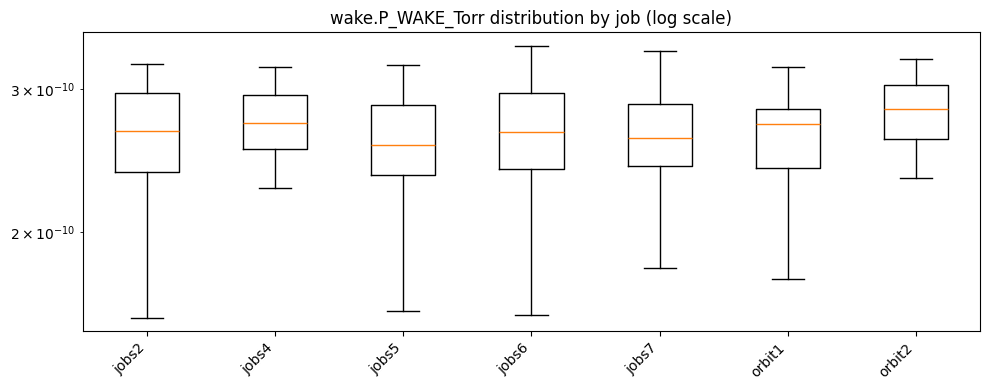

flux_col: wake.Fwafer_log_cm2s
mbe_col: wake.mbe_active


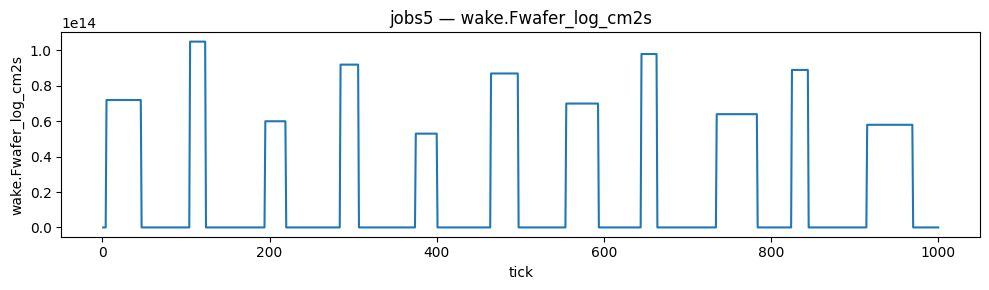

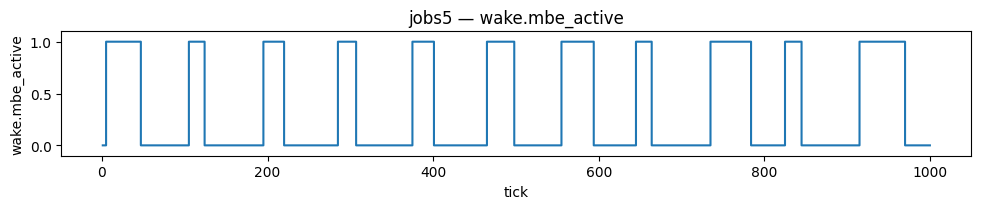

In [32]:
job_to_plot = df["job_name"].value_counts().index[0]
d = df[df["job_name"] == job_to_plot].sort_values(sim_tick_col).reset_index(drop=True)

wake_p_cols = [c for c in d.columns if c.startswith("wake.P_") and "Torr" in c]
wake_p_cols = wake_p_cols[:6]

print("Job:", job_to_plot)
print("Wake pressure cols:", wake_p_cols)

for c in wake_p_cols:
    plt.figure(figsize=(10, 3))
    plt.plot(d[sim_tick_col], d[c])
    plt.yscale("log")  # pressures are tiny; log scale helps
    plt.title(f"{job_to_plot} — {c} (log scale)")
    plt.xlabel(sim_tick_col)
    plt.ylabel("Torr")
    plt.tight_layout()
    plt.show()

# choose one wake pressure to compare across jobs
candidate = None
for c in df.columns:
    if c.startswith("wake.P_WAKE"):
        candidate = c
        break
if candidate is None:
    for c in df.columns:
        if c.startswith("wake.P_") and "Torr" in c:
            candidate = c
            break

print("Comparing column:", candidate)

if candidate:
    # sample to keep it fast if huge
    tmp = df[["job_name", candidate]].dropna()
    jobs = tmp["job_name"].unique().tolist()
    data = [tmp[tmp["job_name"] == j][candidate].values for j in jobs]

    plt.figure(figsize=(10, 4))
    plt.boxplot(data, labels=jobs, showfliers=False)
    plt.yscale("log")
    plt.xticks(rotation=45, ha="right")
    plt.title(f"{candidate} distribution by job (log scale)")
    plt.tight_layout()
    plt.show()
else:
    print("No wake pressure column found.")


job_to_plot = df["job_name"].value_counts().index[0]
d = df[df["job_name"] == job_to_plot].sort_values(sim_tick_col).reset_index(drop=True)

flux_col = None
for c in d.columns:
    if "Fwafer" in c or "flux" in c.lower():
        flux_col = c
        break

mbe_col = None
for c in d.columns:
    if c.lower().endswith("mbe_active") or "mbe_active" in c.lower():
        mbe_col = c
        break

print("flux_col:", flux_col)
print("mbe_col:", mbe_col)

if flux_col:
    plt.figure(figsize=(10, 3))
    plt.plot(d[sim_tick_col], d[flux_col])
    plt.title(f"{job_to_plot} — {flux_col}")
    plt.xlabel(sim_tick_col)
    plt.ylabel(flux_col)
    plt.tight_layout()
    plt.show()

if mbe_col:
    plt.figure(figsize=(10, 2.2))
    plt.step(d[sim_tick_col], d[mbe_col], where="post")
    plt.title(f"{job_to_plot} — {mbe_col}")
    plt.xlabel(sim_tick_col)
    plt.ylabel(mbe_col)
    plt.ylim(-0.1, 1.1)
    plt.tight_layout()
    plt.show()


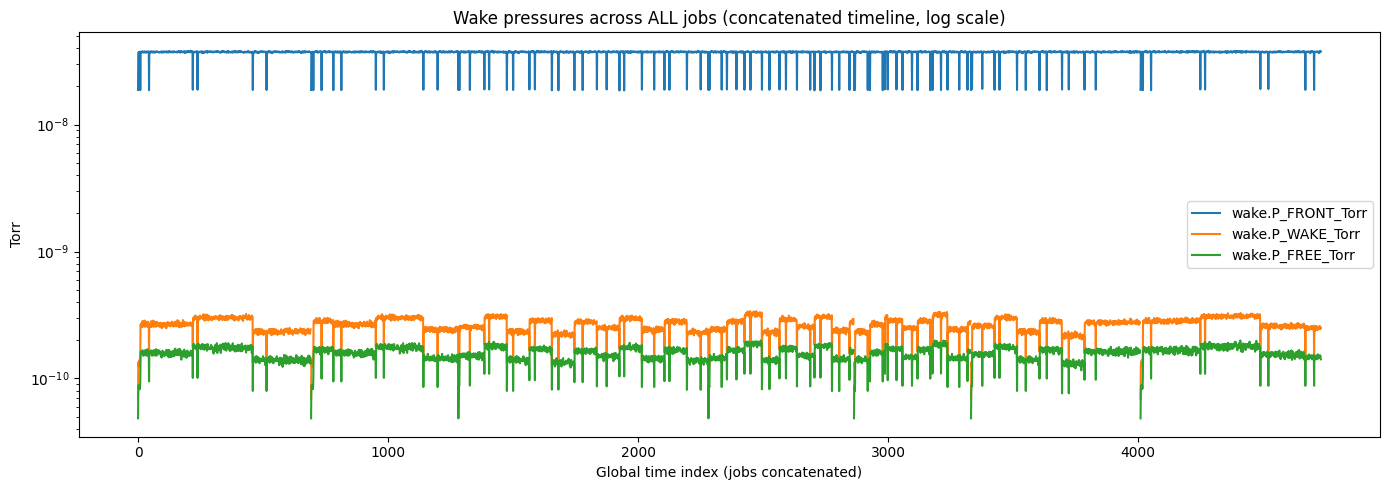

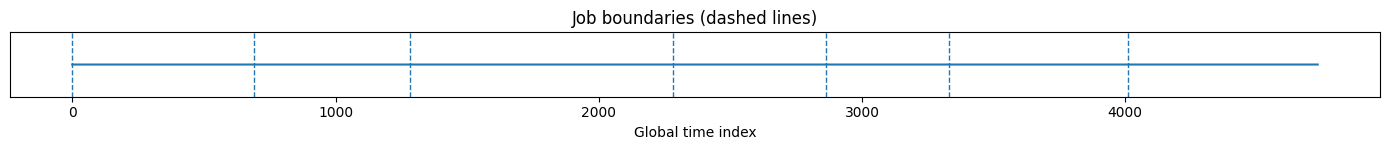

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# master tick col (from your aggregation)
sim_tick_col = df["sim_tick_col"].mode().iloc[0] if "sim_tick_col" in df.columns else "tick"

# pick the 3 wake Torr series you want (edit if you prefer different 3)
series = ["wake.P_FRONT_Torr", "wake.P_WAKE_Torr", "wake.P_FREE_Torr"]
missing = [c for c in series if c not in df.columns]
if missing:
    raise RuntimeError(f"Missing wake columns: {missing}. Available wake cols: {[c for c in df.columns if c.startswith('wake.P_')]}")

# create a global x-axis so we can plot ALL subdirs in one continuous line chart
# (job_id gives each job its own segment on the x-axis in order)
job_order = df["job_name"].dropna().unique().tolist()
job_to_id = {j: i for i, j in enumerate(job_order)}

tmp = df[["job_name", "row_in_job", sim_tick_col] + series].copy()
tmp["job_id"] = tmp["job_name"].map(job_to_id)

# sort so lines connect consistently within each job segment
tmp = tmp.sort_values(["job_id", "row_in_job"]).reset_index(drop=True)

# global index = concatenated timeline across all jobs
tmp["global_x"] = tmp.groupby("job_id").cumcount()
offsets = tmp.groupby("job_id")["global_x"].max().fillna(-1).astype(int) + 1
offsets = offsets.cumsum().shift(fill_value=0)
tmp["global_x"] = tmp["global_x"] + tmp["job_id"].map(offsets)

plt.figure(figsize=(14, 5))
for c in series:
    y = tmp[c].to_numpy(dtype=float)
    # avoid log issues
    y = np.where(y <= 0, np.nan, y)
    plt.plot(tmp["global_x"], y, label=c)

plt.yscale("log")
plt.title("Wake pressures across ALL jobs (concatenated timeline, log scale)")
plt.xlabel("Global time index (jobs concatenated)")
plt.ylabel("Torr")
plt.legend()
plt.tight_layout()
plt.show()

# optional: draw vertical separators between jobs
plt.figure(figsize=(14, 1.6))
plt.plot(tmp["global_x"], np.zeros_like(tmp["global_x"]))
for j, off in offsets.items():
    plt.axvline(off, linestyle="--", linewidth=1)
plt.title("Job boundaries (dashed lines)")
plt.xlabel("Global time index")
plt.yticks([])
plt.tight_layout()
plt.show()


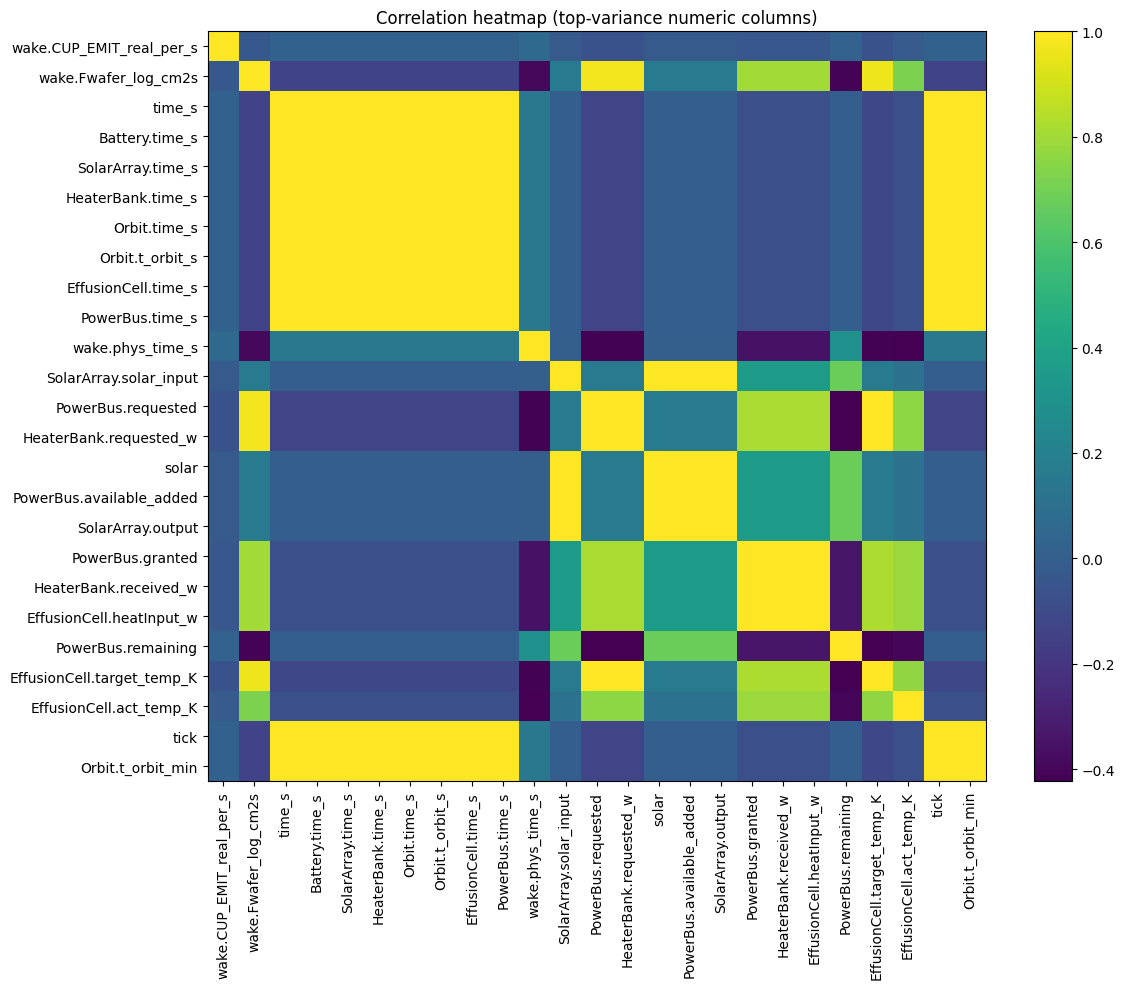

In [ ]:
num_df = df.select_dtypes(include=[np.number]).copy()
# drop obvious non-features if present
for c in ["row_in_job"]:
    if c in num_df.columns:
        num_df = num_df.drop(columns=[c])

var = num_df.var(numeric_only=True).sort_values(ascending=False)
keep = var.head(25).index.tolist()

corr = num_df[keep].corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(keep)), keep, rotation=90)
plt.yticks(range(len(keep)), keep)
plt.colorbar()
plt.title("Correlation heatmap (top-variance numeric columns)")
plt.tight_layout()
plt.show()
    